In [53]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
psi_12 = np.array([1, 0 , 0 , 1])
psi_34 = psi_12
psi_56 = psi_12
Psi = np.kron(np.kron(psi_12, psi_34 ),psi_56)
# 12 34 56

In [3]:
m_13 = np.random.randn(4) 
m_13 = m_13/np.linalg.norm(m_13)
m_25 = m_13
m_46 = m_13 

In [47]:
def MKron(m_13): 
    m_13 = m_13/np.linalg.norm(m_13)
    m_25 = m_13
    m_46 = m_13
    M1 = np.kron(np.kron(m_13,m_25),m_46)
    M = M1.reshape(6*[2])
    M = np.transpose(M,[0,2,1,4,3,5]).flatten()
    return M

def infidelity(m, Psi):
    Inf = 1 - abs(np.vdot(MKron(m),Psi))**2
    return Inf

def CSPSA(m,Psi,G,k):
    out = []
    m_13 = m/np.linalg.norm(m)
    m_25 = m_13
    m_46 = m_13
    M = MKron(m_13)
    for i in range(k):
        # k: iteraciones. psi: estado
        # a = G[0], A = G[1], b = G[2], s = G[3], t = G[4]
        alpha = G[0]/(k+1+G[1])**G[3]
        beta  = G[2]/(k+1)**G[4]
        delta = (1j)**(np.random.randint(1, 5, 4))
        
        Mmas =  m + (beta*delta).flatten()
        Mmen =  m - (beta*delta).flatten()
           
        Fmas = np.real(infidelity(Mmas,Psi))
        Fmen = np.real(infidelity(Mmen,Psi))
          
        grad = np.divide(Fmas - Fmen,2*beta*delta.conj())
        
        m = m - alpha*grad
        m = m/np.linalg.norm(m)
        
        Out = infidelity(m,Psi)
        out.append(Out)
    return out

In [88]:
G = [3, 0, 0.2, 0.602, 0.101]
m = np.random.randn(4) + 1j*np.random.randn(4)

psi_12 = np.array([1, 0 , 0 , 1])/np.sqrt(2)
#psi_12 = np.array([1, 0 , 0 , 0])
psi_34 = psi_12
psi_56 = psi_12
Psi = np.kron( np.kron(psi_12, psi_34 ),psi_56)

k = 200

Out = CSPSA(m,Psi,G,k)
Out[-1]

0.8750164797528344

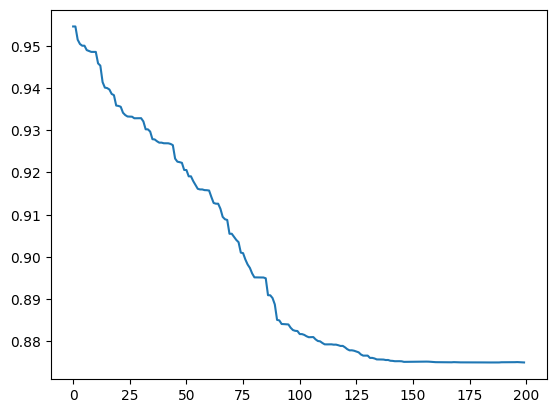

In [89]:
plt.plot(Out)

In [35]:
m_13 = m = np.random.randn(4) + 1j*np.random.randn(4)

psi_12 = np.array([1, 0 , 0 , 1])
psi_34 = psi_12
psi_56 = psi_12
Psi = np.kron( np.kron(psi_12, psi_34 ),psi_56)


0.9727591785998139

In [32]:
m = np.random.randn(4) + 1j*np.random.randn(4)
G = [0.2, 0, 0.2, 0.602, 0.101]

In [33]:
alpha = G[0]/(k+1+G[1])**G[3]
beta  = G[2]/(k+1)**G[4]
delta = (1j)**(np.random.randint(1, 5, 4))

Mmas =  m + beta*delta
Mmen =  m - beta*delta
        
      


(4,)

In [12]:
a = np.array([1,0])
b = a.reshape(2,1)
a+b

array([[2, 1],
       [1, 0]])

In [28]:
delta = (1j)**(np.random.randint(1, 5, 4))
delta.shape

(4,)